In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os


In [21]:
ROOT_DIR = Path(r"D:\Fall 25\ML for Production\Project\shawshank_prediction_team-17")

TELEMETRY_PATH = ROOT_DIR / "dataset" / "telemetry_recs_dec.txt"
RATINGS_PATH = ROOT_DIR / "dataset" / "ratings_dec.log"


# Columns: timestamp, session_type (cold/warm), user_id, latency, model_version, recs
telemetry_cols = [
    "timestamp",
    "session_type",
    "user_id",
    "latency",
    "model_version",
    "recs",
]

telemetry_df = pd.read_csv(
    TELEMETRY_PATH,
    header=None,
    names=telemetry_cols,
    dtype={"user_id": "Int64"},
)

# Strip spaces from model_version and recs if present (e.g., " v1" -> "v1")
telemetry_df["model_version"] = telemetry_df["model_version"].astype(str).str.strip()
telemetry_df["recs"] = telemetry_df["recs"].astype(str).str.strip()



In [11]:

# Split pipe-separated movie list
telemetry_df["rec_list"] = telemetry_df["recs"].str.split("|")

# Keep one row per recommended movie
exploded = telemetry_df.explode("rec_list").reset_index(drop=True)

# rec_list entries look like "the+dark+knight+2008"
exploded["movie_raw"] = exploded["rec_list"].astype(str)

# Convert + to spaces for readability
exploded["movie"] = exploded["movie_raw"].str.replace("+", " ", regex=False)

# Rank within each session: 1 = top position
exploded["rank"] = exploded.groupby(["timestamp", "user_id"])["movie"].cumcount() + 1



In [12]:
# -------------------------------------------------------------------
# 3. Aggregate: overall recommendation frequency per movie
# -------------------------------------------------------------------
movie_counts = (
    exploded.groupby("movie")
    .size()
    .sort_values(ascending=False)
    .rename("rec_count")
    .reset_index()
)

# Optionally restrict to movies recommended at least X times
min_recs = 10
popular_movies = movie_counts.query("rec_count >= @min_recs")

print("Number of unique movies:", movie_counts.shape[0])
print("Number of movies with at least", min_recs, "recommendations:", popular_movies.shape[0])
print("\nTop 20 by recommendation count:")
print(movie_counts.head(20))



Number of unique movies: 25
Number of movies with at least 10 recommendations: 20

Top 20 by recommendation count:
                                                movie  rec_count
0                                             up 2009        193
1                                      inception 2010        193
2                                   interstellar 2014        188
3                monty python and the holy grail 1975        186
4                                     big hero 6 2014        184
5                       the shawshank redemption 1994        180
6                                the dark knight 2008        179
7                                       iron man 2008        179
8                 one flew over the cuckoos nest 1975        178
9                        raiders of the lost ark 1981        176
10                                         alien 1979        175
11                                      coraline 2009        175
12  the lord of the rings the fellowship

C:\Users\jayan\AppData\Local\Temp\ipykernel_35280\3136133854.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


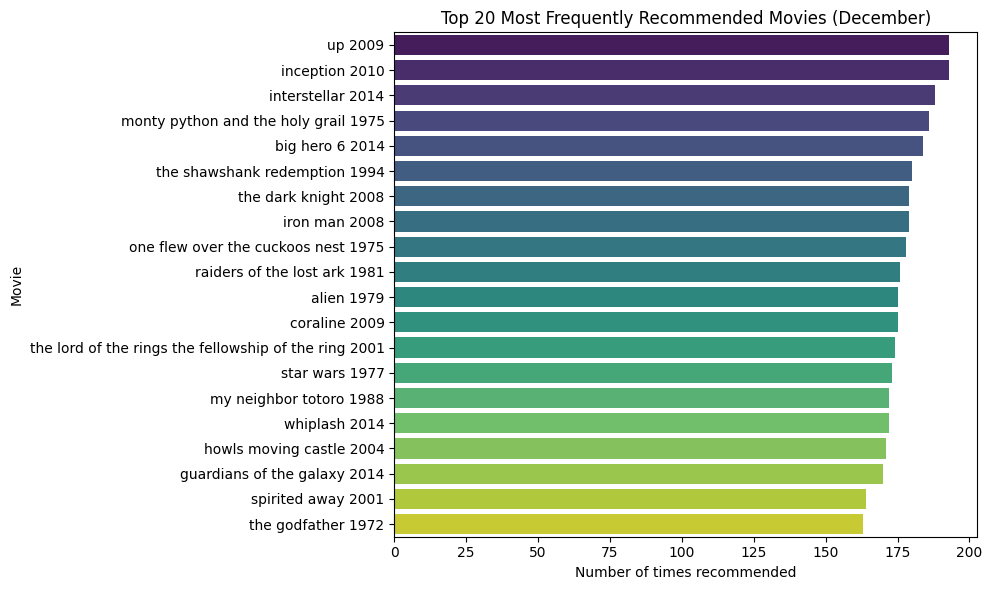

In [13]:
top_n = 20
top_movies = movie_counts.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_movies,
    x="rec_count",
    y="movie",
    palette="viridis"
)
plt.title(f"Top {top_n} Most Frequently Recommended Movies (December)")
plt.xlabel("Number of times recommended")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()



C:\Users\jayan\AppData\Local\Temp\ipykernel_35280\1326289900.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


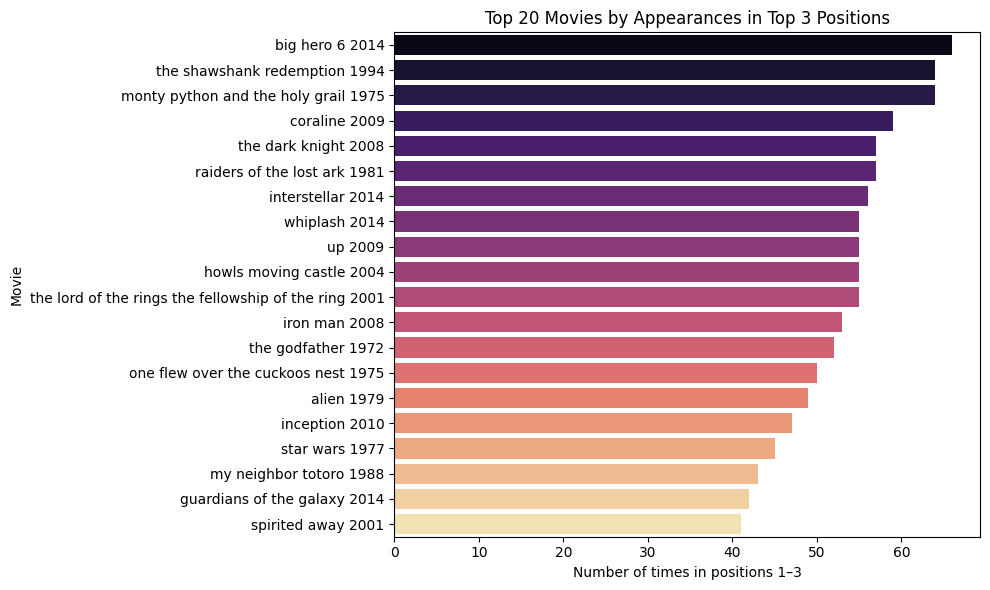

In [16]:
# Concentration of exposure in top ranks
top_k = 3
rank_mask = exploded["rank"] <= top_k

rank_counts = (
    exploded[rank_mask]
    .groupby("movie")
    .size()
    .sort_values(ascending=False)
    .rename("top_k_rec_count")
    .reset_index()
)

top_rank_movies = rank_counts.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_rank_movies,
    x="top_k_rec_count",
    y="movie",
    palette="magma"
)
plt.title(f"Top {top_n} Movies by Appearances in Top {top_k} Positions")
plt.xlabel(f"Number of times in positions 1–{top_k}")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()




Share of all recommendations captured by head movies:
   head_size  share_of_all_recs
0          5           0.265915
1         10           0.517183
2         20           0.998592
3         50           1.000000


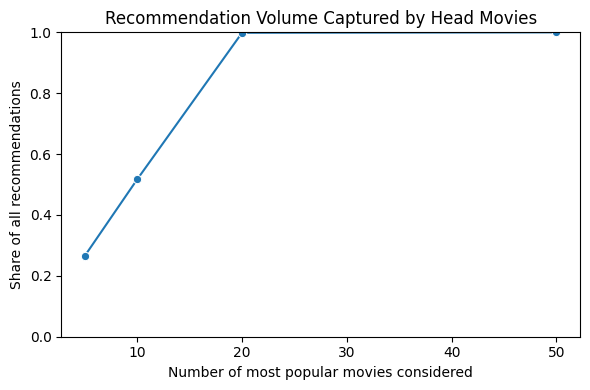

In [17]:
total_recs = len(exploded)
head_sizes = [5, 10, 20, 50]

head_share = []
for h in head_sizes:
    share = movie_counts.head(h)["rec_count"].sum() / total_recs
    head_share.append({"head_size": h, "share_of_all_recs": share})

head_share_df = pd.DataFrame(head_share)
print("\nShare of all recommendations captured by head movies:")
print(head_share_df)

plt.figure(figsize=(6, 4))
sns.lineplot(
    data=head_share_df,
    x="head_size",
    y="share_of_all_recs",
    marker="o"
)
plt.title("Recommendation Volume Captured by Head Movies")
plt.xlabel("Number of most popular movies considered")
plt.ylabel("Share of all recommendations")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()




Top recommended movies and how often they are rated:
                                                movie  rec_count  rating_count
0                                             up 2009        193            19
1                                      inception 2010        193            10
2                                   interstellar 2014        188            13
3                monty python and the holy grail 1975        186            10
4                                     big hero 6 2014        184            10
5                       the shawshank redemption 1994        180            23
6                                the dark knight 2008        179            20
7                                       iron man 2008        179            10
8                 one flew over the cuckoos nest 1975        178             8
9                        raiders of the lost ark 1981        176            12
11                                      coraline 2009        175             

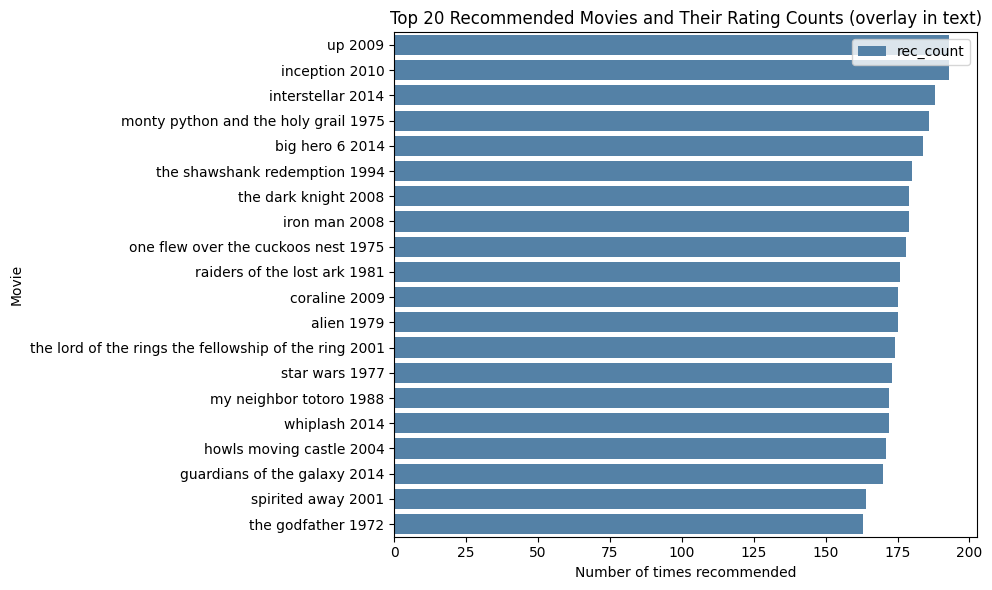

In [22]:
ratings_path = RATINGS_PATH


ratings_df = pd.read_csv(
    ratings_path,
    header=None,
    names=["timestamp", "user_id", "movie_raw", "rating"],
)
ratings_df["movie"] = ratings_df["movie_raw"].astype(str).str.replace("+", " ", regex=False)

rating_counts = (
    ratings_df.groupby("movie")
    .size()
    .sort_values(ascending=False)
    .rename("rating_count")
    .reset_index()
)

# Merge top recommendation movies with ratings to show overlap
head = movie_counts.head(20).merge(rating_counts, on="movie", how="left")

print("\nTop recommended movies and how often they are rated:")
print(head.sort_values("rec_count", ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=head.sort_values("rec_count", ascending=False),
    x="rec_count",
    y="movie",
    color="steelblue",
    label="rec_count"
)
plt.title("Top 20 Recommended Movies and Their Rating Counts (overlay in text)")
plt.xlabel("Number of times recommended")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()
